# Logistic Regression

### Logistic Regression with L2 regularization

Accuracy: 0.4956647398843931
              precision    recall  f1-score   support

         EDM       0.56      0.59      0.57       191
      HipHop       0.53      0.52      0.52       194
       Latin       0.45      0.46      0.45       207
         Pop       0.41      0.46      0.43       233
         R&B       0.43      0.29      0.35       146
         Rap       0.43      0.38      0.40       185
        Rock       0.62      0.69      0.65       228

    accuracy                           0.50      1384
   macro avg       0.49      0.48      0.48      1384
weighted avg       0.49      0.50      0.49      1384



/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


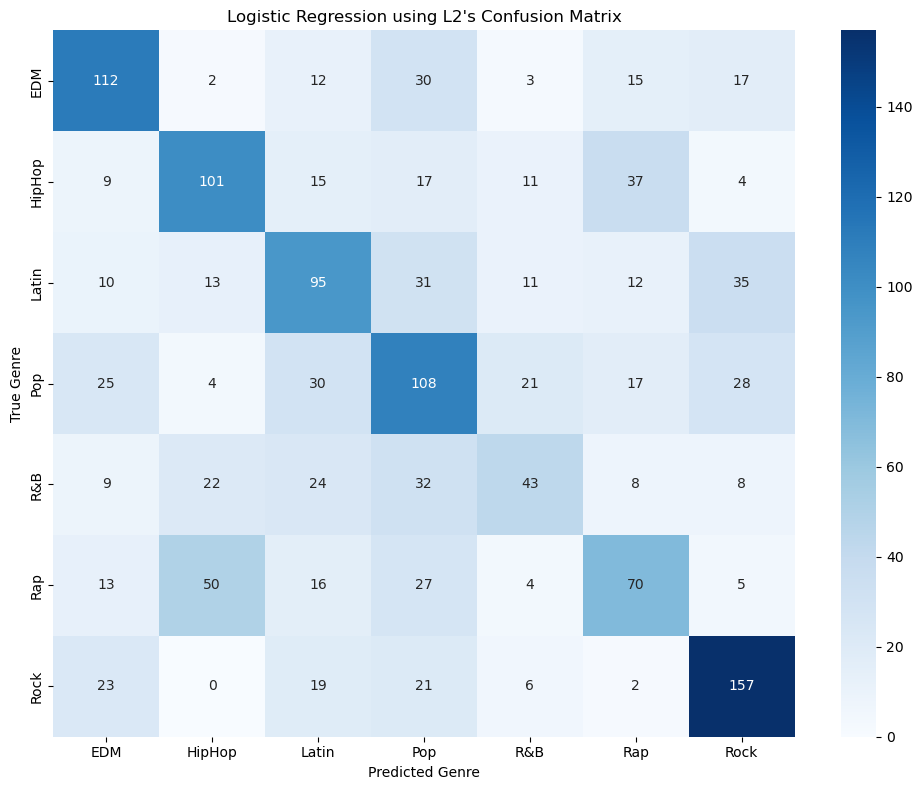

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

X_train = pd.read_csv('../data/X_train_scaled.csv')
X_test = pd.read_csv('../data/X_test_scaled.csv')
Y_train = pd.read_csv('../data/Y_train.csv') 
Y_test = pd.read_csv('../data/Y_test.csv')
genre_names = [
    "EDM",
    "HipHop",
    "Latin",
    "Pop",
    "R&B",
    "Rap",
    "Rock"
]
y_train = Y_train.values.ravel()
y_test = Y_test.values.ravel()

# --------------------Model Train--------------------------------
# Logistic Regression model using L2 regularization
model1 = LogisticRegression(
    l1_ratio=0, # L2
    C=0.3,
    solver='saga',
    max_iter=1000
)

model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)
# ---------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# per-class precision/recall/F1 + overall summary
print(
    classification_report(
        y_test,
        y_pred,
        target_names=genre_names
    )
)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=genre_names,
    yticklabels=genre_names
)

plt.xlabel("Predicted Genre")
plt.ylabel("True Genre")
plt.title("Logistic Regression using L2's Confusion Matrix")

plt.tight_layout()
plt.show()




### Logistic Regression using L1 regularization

Accuracy: 0.4956647398843931
[[112   2  12  30   3  15  17]
 [  9 101  15  17  11  37   4]
 [ 10  13  95  31  11  12  35]
 [ 25   4  30 108  21  17  28]
 [  9  22  24  32  43   8   8]
 [ 13  50  16  27   4  70   5]
 [ 23   0  19  21   6   2 157]]
Accuracy: 0.4956647398843931
              precision    recall  f1-score   support

         EDM       0.56      0.59      0.57       191
      HipHop       0.53      0.52      0.52       194
       Latin       0.45      0.46      0.45       207
         Pop       0.41      0.46      0.43       233
         R&B       0.43      0.29      0.35       146
         Rap       0.43      0.38      0.40       185
        Rock       0.62      0.69      0.65       228

    accuracy                           0.50      1384
   macro avg       0.49      0.48      0.48      1384
weighted avg       0.49      0.50      0.49      1384



/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


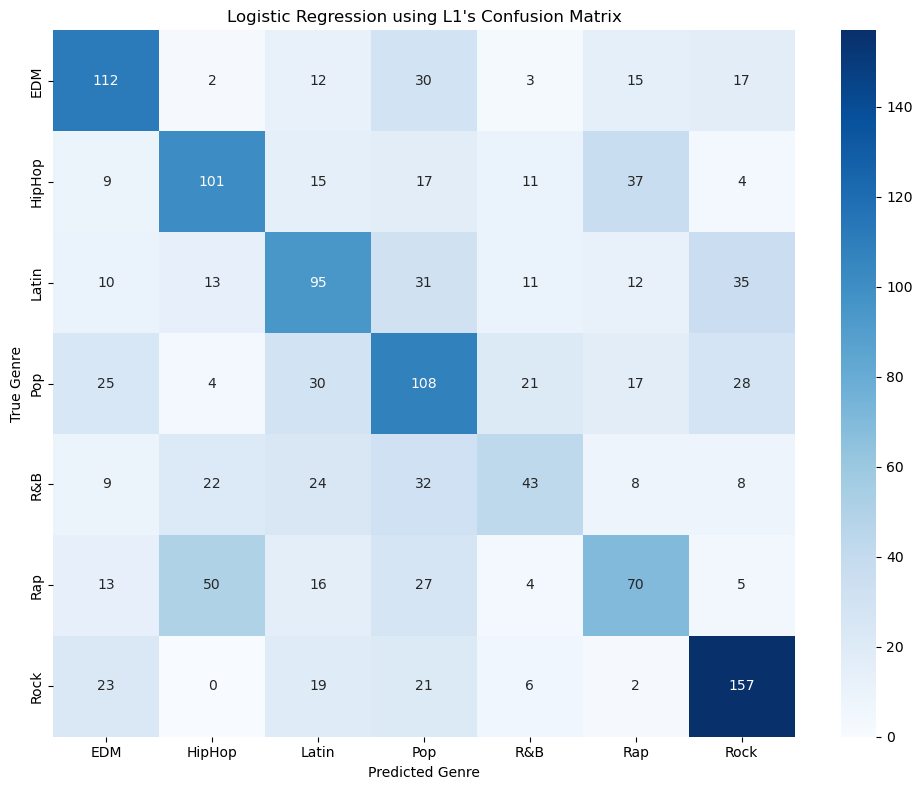

In [2]:
# Logistic Regression using 'L1' regularization
model = LogisticRegression(
    l1_ratio=1,
    C=0.3,
    solver='saga',
    max_iter=1000
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy)
print(
    classification_report(
        y_test,
        y_pred,
        target_names=genre_names
    )
)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=genre_names,
    yticklabels=genre_names
)

plt.xlabel("Predicted Genre")
plt.ylabel("True Genre")
plt.title("Logistic Regression using L1's Confusion Matrix")

plt.tight_layout()
plt.show()


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-

Best Train Accuracy: 0.5318995120187963
Best Test Accuracy: 0.4985549132947977


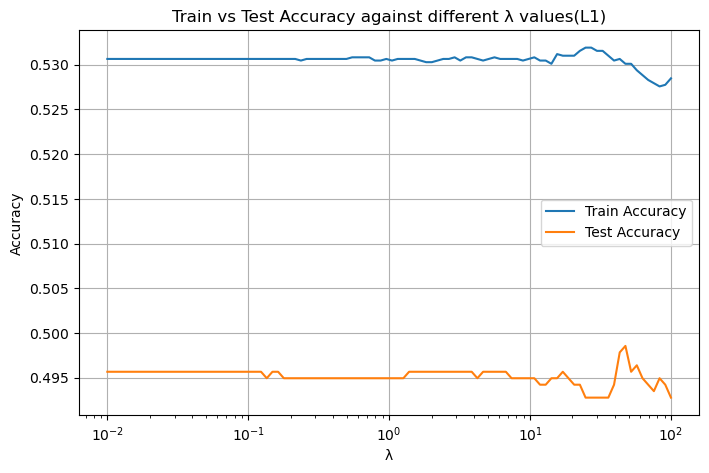

In [3]:
# An array from 10^-2 to 10^2
lambda_values = np.logspace(-2, 2, 100)

train_accuracies = []
test_accuracies = []

for l in lambda_values:

    model = LogisticRegression(
        l1_ratio=1,
        C=1/l,
        solver='saga',
        max_iter=1000
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_accuracies.append(
        accuracy_score(y_train, y_train_pred)
    )

    test_accuracies.append(
        accuracy_score(y_test, y_test_pred)
    )

print("Best Train Accuracy:", max(train_accuracies))
print("Best Test Accuracy:", max(test_accuracies))

plt.figure(figsize=(8, 5))

plt.plot(
    lambda_values,
    train_accuracies,
    label='Train Accuracy'
)

plt.plot(
    lambda_values,
    test_accuracies,
    label='Test Accuracy'
)

plt.grid(True)

plt.xscale('log')

plt.xlabel("λ")
plt.ylabel("Accuracy")

plt.title("Train vs Test Accuracy against different λ values(L1)")

plt.legend()

plt.show()

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-

Best Train Accuracy: 0.5318995120187963
Best Test Accuracy: 0.4985549132947977


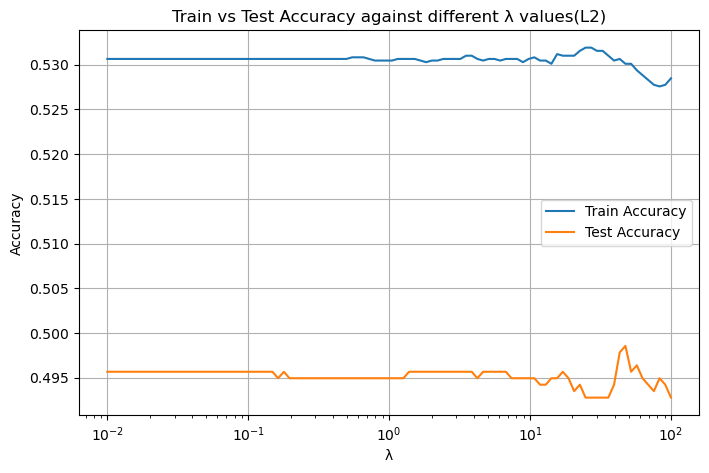

In [4]:
lambda_values = np.logspace(-2, 2, 100)

train_accuracies = []
test_accuracies = []

for l in lambda_values:

    model = LogisticRegression(
        l1_ratio=0,
        C=1/l,
        solver='saga',
        max_iter=1000
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_accuracies.append(
        accuracy_score(y_train, y_train_pred)
    )

    test_accuracies.append(
        accuracy_score(y_test, y_test_pred)
    )

print("Best Train Accuracy:", max(train_accuracies))
print("Best Test Accuracy:", max(test_accuracies))

plt.figure(figsize=(8, 5))

plt.plot(
    lambda_values,
    train_accuracies,
    label='Train Accuracy'
)

plt.plot(
    lambda_values,
    test_accuracies,
    label='Test Accuracy'
)

plt.grid(True)

plt.xscale('log')

plt.xlabel("λ")
plt.ylabel("Accuracy")

plt.title("Train vs Test Accuracy against different λ values(L2)")

plt.legend()

plt.show()

In [5]:
from itertools import combinations

c_values = np.logspace(-2, 2, 10)
results = []

columns = list(X_train.columns)
# Check the combination of {1/λ, number of columns dropped} can give a better model performance
for c in c_values:
    # 2-4 columns are dropped
    for k in range(2, 5):
        # Iterate each combination of features given k dropped columns
        for cols_to_drop in combinations(columns, k):

            X_train_drop = X_train.drop(columns=list(cols_to_drop))
            X_test_drop = X_test.drop(columns=list(cols_to_drop))

            model = LogisticRegression(
                C=c,
                solver='saga',
                max_iter=1000
            )

            model.fit(X_train_drop, y_train)
            y_train_pred = model.predict(X_train_drop)
            y_pred = model.predict(X_test_drop)
            acc_train = accuracy_score(y_train, y_train_pred)
            acc = accuracy_score(y_test, y_pred)
            # Append result in 
            results.append({
                'C': c,
                'k': k,
                'Dropped Features': cols_to_drop,
                'Train Accuracy': acc_train,
                'Test Accuracy': acc
            })


results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='Test Accuracy',
    ascending=False
)

print(results_df.head(20))

               C  k                   Dropped Features  Train Accuracy  \
49      0.010000  2       (instrumentalness, liveness)        0.518706   
599     0.027826  2       (instrumentalness, liveness)        0.521959   
179     0.010000  3  (key, instrumentalness, liveness)        0.518887   
31      0.010000  2                    (key, liveness)        0.523044   
581     0.027826  2                    (key, liveness)        0.526839   
1279    0.077426  3  (key, instrumentalness, liveness)        0.520875   
2929    1.668101  3  (key, instrumentalness, liveness)        0.521055   
729     0.027826  3  (key, instrumentalness, liveness)        0.522501   
1131    0.077426  2                    (key, liveness)        0.527200   
1149    0.077426  2       (instrumentalness, liveness)        0.520513   
4029   12.915497  3  (key, instrumentalness, liveness)        0.520875   
3479    4.641589  3  (key, instrumentalness, liveness)        0.521055   
5129  100.000000  3  (key, instrumenta

Dropping feature doesn't improve logistic regression model a lot